<font size="5" color="red"><b>ch2. 군집분석</b></font>
# 1절. 군집모델(클러스터링)
-클러스터(cluster) : 독립변수의특성이유사한데이터의그룹
-클러스터링(clustering) : 주어진데이터를여러개의클러스터로구분하는것
1) 중심기반클러스터링(K-Means) : https://commons.wikimedia.org/wiki/File:KMeans-Gaussian-data.svg
<img src="https://upload.wikimedia.org/wikipedia/commons/e/e5/KMeans-Gaussian-data.svg"
style="display: block; margin-left: 0; width: 20%;">
2) 연결기반클러스터링(DBSCAN) : https://commons.wikimedia.org/wiki/File:DBSCAN-density-data.svg
<img src="https://upload.wikimedia.org/wikipedia/commons/0/05/DBSCAN-density-data.svg"
width="300"
style="display: block; margin-left: 0; width: 20%;">
3) 밀도기반클러스터링(DBSCAN의변형으로OPTICS) : https://commons.wikimedia.org/wiki/File:OPTICS-Gaussian-data.svg
<img src="https://upload.wikimedia.org/wikipedia/commons/8/8a/OPTICS-Gaussian-data.svg"
width="300"
style="display: block; margin-left: 0; width: 20%;">

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
# sklearn의 로직들이 멀티 쓰레드로 실행

# 2절. K-Means 클러스터링
- 가장 단순하고 빠른 클러스터링 알고리즘
- 클러스터의 중심을 찾아가는 알고리즘
- 세부알고리즘 : 교안 6p

In [3]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'
# 한글설정
plt.rc('font', family='Malgun Gothic') # 윈도우즈
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지

In [13]:
# 분류를 위한 가상의 데이터 생성
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=20, # 데이터 갯수(기본값 100)
                           n_features=2, # 독립변수갯수(기본값 20)
                           n_informative=2, # 종속변수에 영향을 미치는 독립변수 갯수
                           n_redundant=0, # 종속변수에 영향을 미치지 않는 독립변수 갯수
                           n_classes=2, # 종속변수의 클래스 수
                           n_clusters_per_class=1, # 각 종속변수 그룹별 서브그룹이 없음
                           random_state=123)
import numpy as np
np.c_[X,y][:3]

array([[ 1.03859554,  2.51175389,  0.        ],
       [ 1.00271366,  1.93521549,  0.        ],
       [-1.6881048 ,  0.02599427,  1.        ]])

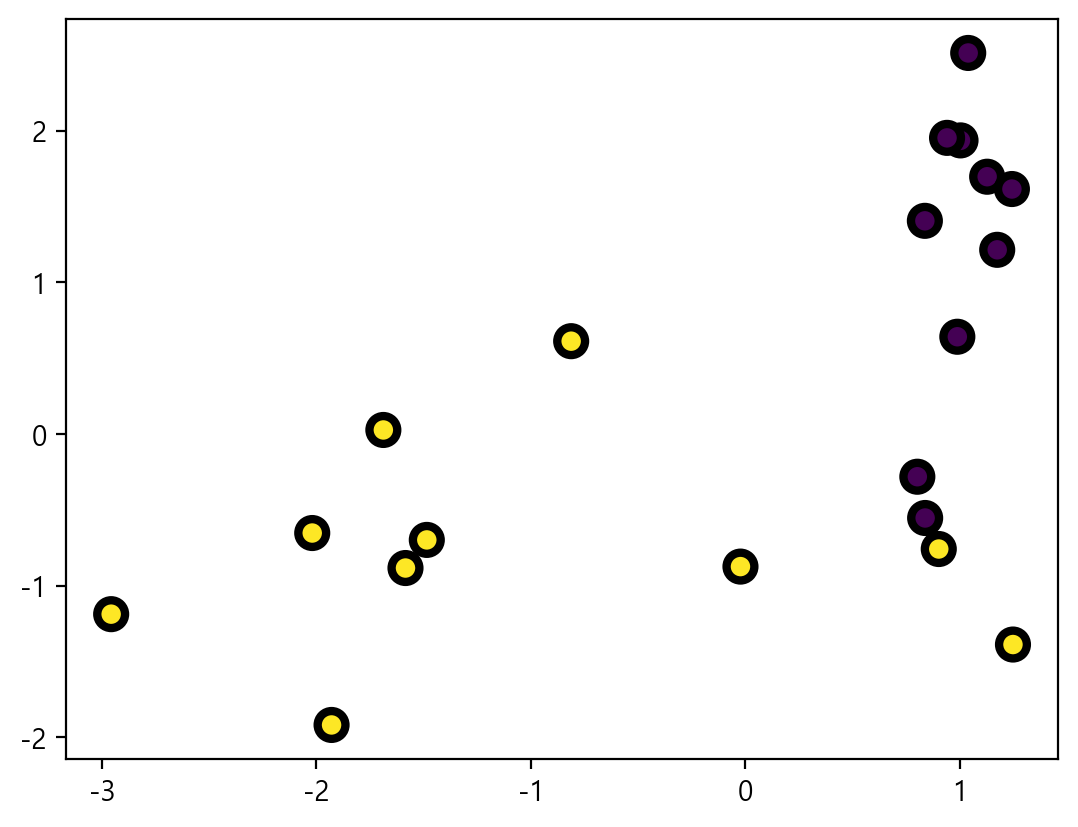

In [16]:
plt.scatter(x=X[:,0], y=X[:,1], c=y, s=100, edgecolors='k', lw=3)

In [18]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=2, # 군의 갯수
               init="k-means++", # 초기중심점을 서로 멀리 초기화 / random(초기중심점랜덤)
               n_init=10, # 각 다른 초기값을 10번 실행해보고 가장 좋은 모델 선택
               max_iter=300) # 각 실행에서 300번 반복(중심 옮기기)

In [19]:
model.fit(X)

KMeans(n_clusters=2, n_init=10)

In [28]:
c0, c1 = model.cluster_centers_ # 모델이 정한 두 중심점
print(c0, c1)

[1.01138251 0.83200493] [-1.56258716 -0.69768199]


In [45]:
print("modelLabel :", model.labels_)
pred = model.predict(X)
print("  예 측 값 :", pred)
print("  실 제 값 :", y)

modelLabel : [0 0 1 0 0 1 0 1 1 0 0 0 0 1 0 1 1 1 0 0]
  예 측 값 : [0 0 1 0 0 1 0 1 1 0 0 0 0 1 0 1 1 1 0 0]
  실 제 값 : [0 0 1 1 0 1 0 1 1 0 0 0 0 1 1 1 1 1 0 0]


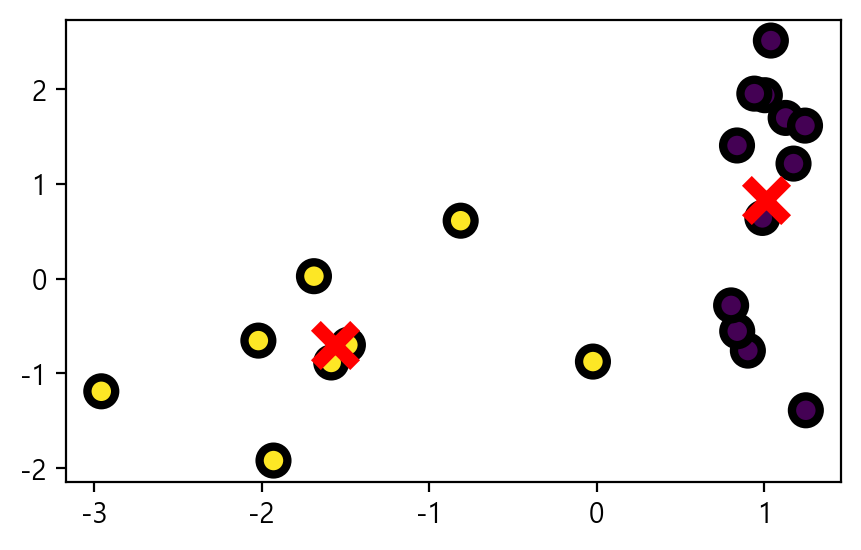

In [34]:
plt.figure(figsize=(5,3))
plt.scatter(x=X[:,0], y=X[:,1], c=pred, s=100, edgecolors='k', lw=3)
plt.scatter(x=c0[0], y=c0[1], s=200, marker='x', lw=5, c='r')
plt.scatter(x=c1[0], y=c1[1], s=200, marker='x', lw=5, c='r')
plt.show()

## cf. Normalizer 적용

In [61]:
import pandas as pd
from sklearn.preprocessing import Normalizer
scaler = Normalizer()
Xnor = scaler.fit_transform(X)
np.c_[X, Xnor][:3]

array([[ 1.03859554,  2.51175389,  0.3821159 ,  0.92411441],
       [ 1.00271366,  1.93521549,  0.46005267,  0.88789162],
       [-1.6881048 ,  0.02599427, -0.99988146,  0.01539667]])

In [62]:
model = KMeans(n_clusters=2, # 군의 갯수
               init="k-means++", # 초기중심점을 서로 멀리 초기화 / random(초기중심점랜덤)
               n_init=10, # 각 다른 초기값을 10번 실행해보고 가장 좋은 모델 선택
               max_iter=300) # 각 실행에서 300번 반복(중심 옮기기)
model.fit(Xnor)

KMeans(n_clusters=2, n_init=10)

In [63]:
model.labels_ # 모델이 그룹핑한 결과

array([0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0])

In [64]:
d0, d1 = model.cluster_centers_ # 모델이 정한 중심점
print(d0, d1)

[0.64128684 0.34902823] [-0.77398837 -0.33522479]


In [65]:
Xnor[model.labels_==0]

array([[ 0.3821159 ,  0.92411441],
       [ 0.46005267,  0.88789162],
       [ 0.76493676, -0.64410538],
       [ 0.51161542,  0.85921456],
       [ 0.83395074, -0.55183889],
       [ 0.55350265,  0.83284742],
       [ 0.94318094, -0.33227958],
       [ 0.43387458,  0.90097328],
       [ 0.60980605,  0.79255068],
       [ 0.66821427, -0.74396888],
       [ 0.83902767,  0.54408875],
       [ 0.69516439,  0.7188508 ]])

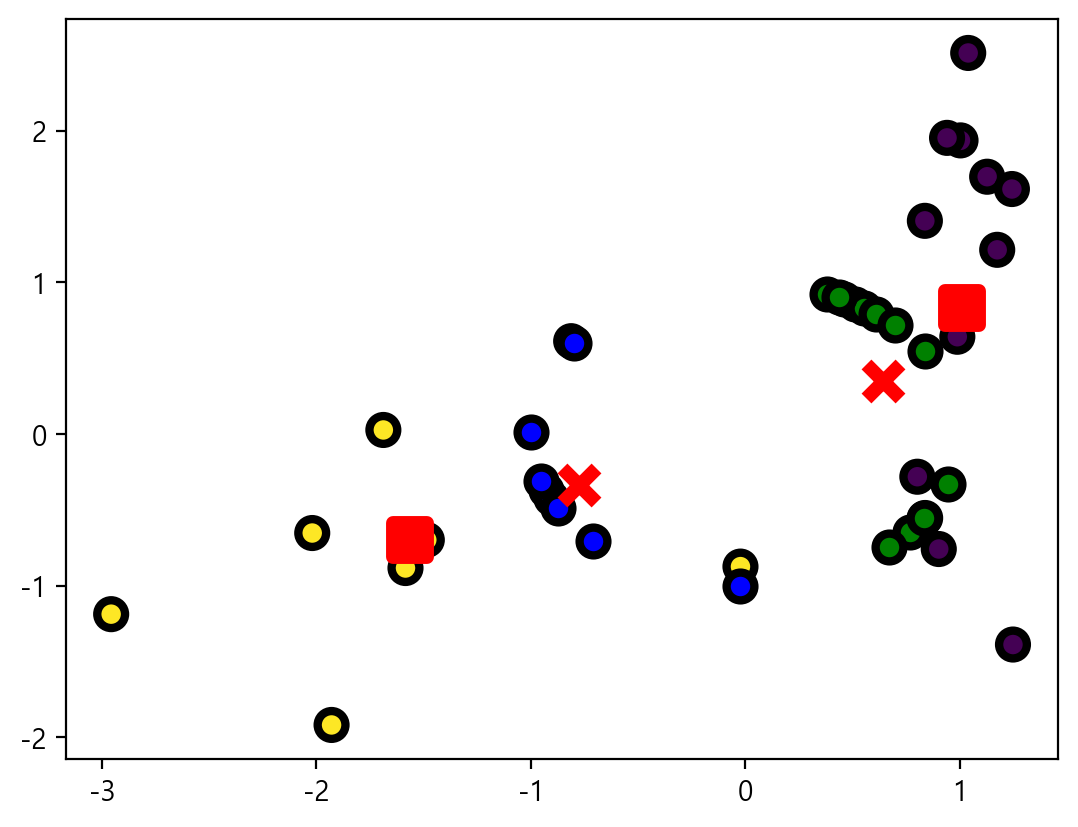

In [73]:
plt.scatter(x=X[:,0], y=X[:,1], c=pred, s=100, edgecolors='k', lw=3 )
plt.scatter(x=c0[0], y=c0[1], s=150, marker='s', lw=5, c='r')
plt.scatter(x=c1[0], y=c1[1], s=150, marker='s', lw=5, c='r')

plt.scatter(x=Xnor[model.labels_==0,0], 
            y=Xnor[model.labels_==0,1], 
            c='g', s=100, edgecolors='k', lw=3 )
plt.scatter(x=Xnor[model.labels_==1,0], 
            y=Xnor[model.labels_==1,1], 
            c='b', s=100, edgecolors='k', lw=3 )
plt.scatter(x=d0[0], y=d0[1], s=150, marker='x', lw=5, c='r')
plt.scatter(x=d1[0], y=d1[1], s=150, marker='x', lw=5, c='r')

plt.show()

In [74]:
from sklearn.datasets import make_classification
import pandas as pd
from sklearn.cluster import KMeans

## K-Means 클러스터링의 한계점(pt13)
- 군의 특성이 다를 경우
    - 크기
    - 군의 밀도
    - 비구형
- 이상치를 포함할 경우 : 이상치를 조정하거나 삭제한 후 클러스터링
### 군의 크기가 다른 경우

In [97]:
np.random.seed(0)
# 평균:-10, 표준편차:2인 10행 2열 데이터 : group0
group0 = np.random.normal(loc = -10, scale= 2, size=(10,2))
y = np.full(group0.shape[0], 0)
group0 = np.c_[group0, y]
group0[:2]

array([[-6.47189531, -9.19968558,  0.        ],
       [-8.04252403, -5.5182136 ,  0.        ]])

In [98]:
# 평균:10, 표준편차:2인 10행 2열 데이터 : group1
group1 = np.random.normal(loc = 10, scale= 2, size=(10,2))
y = np.full(group1.shape[0], 1)
group1 = np.c_[group1, y]
group1[:2]

array([[ 4.89402037, 11.30723719,  1.        ],
       [11.7288724 ,  8.51566996,  1.        ]])

In [99]:
# 평균:0, 표준편차:5인 100행 2열 데이터 : group2
group2 = np.random.normal(loc = 0, scale= 5, size=(100,2))
y = np.full(group2.shape[0], 1)
group2 = np.c_[group2, y]
group2[:2]

array([[-5.24276483, -7.10008969,  1.        ],
       [-8.53135095,  9.75387698,  1.        ]])

In [100]:
data = np.r_[group0, group1, group2]
data[::10], data.shape

(array([[-6.47189531, -9.19968558,  0.        ],
        [ 4.89402037, 11.30723719,  1.        ],
        [-5.24276483, -7.10008969,  1.        ],
        [-3.36230224, -1.79776581,  1.        ],
        [-5.8257492 ,  4.50413243,  1.        ],
        [ 9.41575349, -6.73879531,  1.        ],
        [ 1.88212766, -5.49700395,  1.        ],
        [-7.45628796,  2.19695851,  1.        ],
        [-2.49016225,  9.64766027,  1.        ],
        [-1.76996956, -6.87475647,  1.        ],
        [-1.84590919, -1.19689589,  1.        ],
        [-4.779725  , -1.72990888,  1.        ]]),
 (120, 3))

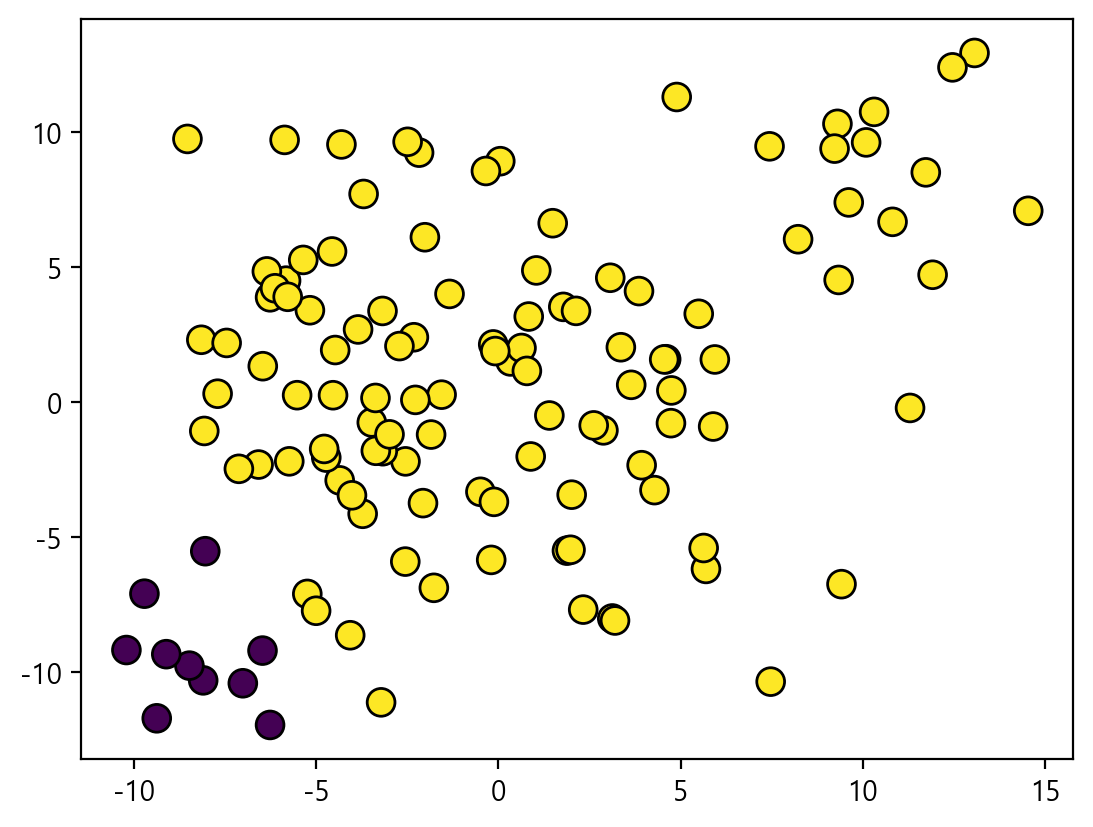

In [101]:
plt.scatter(x=data[:,0], y=data[:,1], c=data[:,2], s=100, edgecolors='k')
plt.show()

In [105]:
model = KMeans(n_clusters=3,
              init="k-means++",
              n_init="auto",
              max_iter=300)
model.fit(data[:, :2])

KMeans(n_clusters=3, n_init='auto')

In [106]:
c = model.cluster_centers_ # 중심점
c

array([[-3.23795138,  3.79797742],
       [ 7.93234415,  5.526175  ],
       [-2.11638402, -5.40013046]])

In [109]:
pred = model.predict(data[:, :2]) # 모델이 클러스터링한 결과
pred = model.labels_

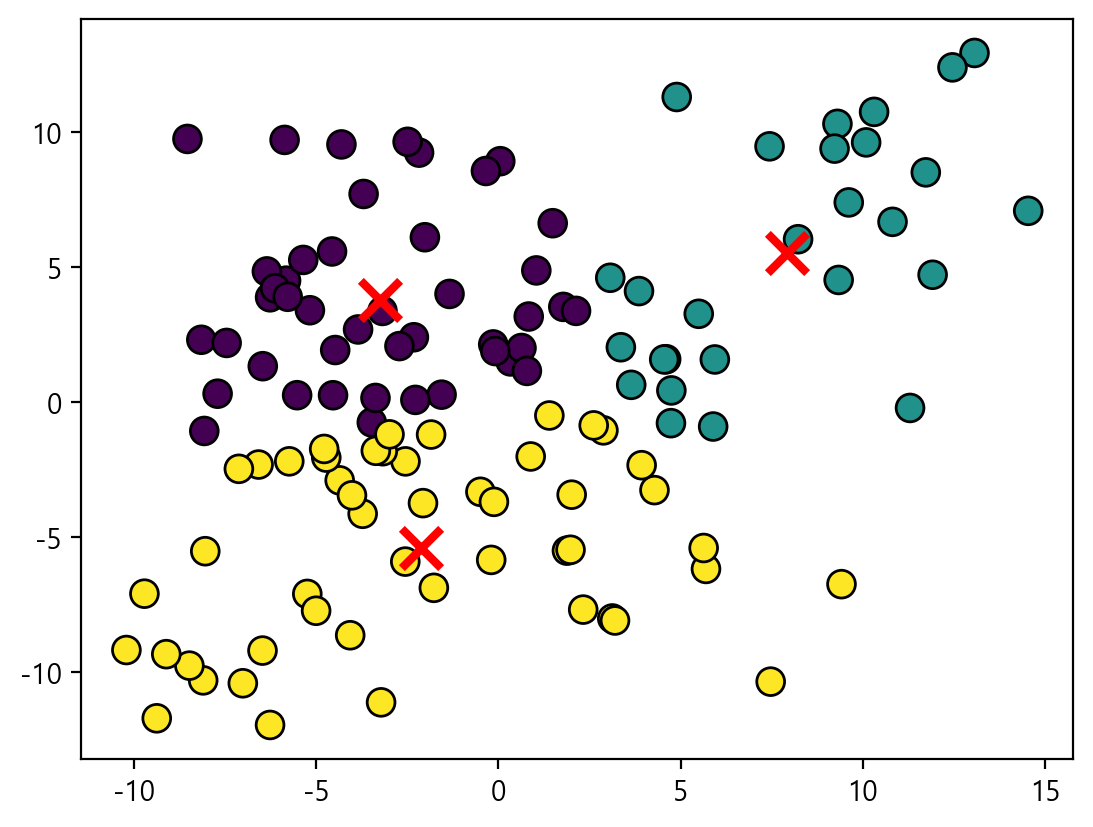

In [110]:
plt.scatter(x=data[:,0], y=data[:,1], c=pred, s=100, edgecolors='k')
plt.scatter(x=c[:,0], y=c[:,1], c='r', marker='x', s=200, lw=3)
plt.show()

In [112]:
model = KMeans(n_clusters=6,
               init="k-means++",
               n_init=10)
model.fit(data[:,:2])

KMeans(n_clusters=6, n_init=10)

In [113]:
c = model.cluster_centers_ # 중심점
pred = model.labels_  # 모델이 클러스터한 결과
pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 0, 1,
       3, 1, 3, 3, 4, 2, 2, 3, 3, 0, 4, 3, 3, 2, 4, 4, 3, 3, 1, 4, 5, 2,
       1, 1, 2, 2, 1, 2, 4, 1, 1, 3, 5, 5, 1, 1, 2, 2, 4, 2, 3, 1, 2, 3,
       3, 1, 2, 4, 3, 2, 5, 1, 3, 1, 3, 4, 4, 3, 1, 2, 1, 0, 2, 2, 4, 1,
       3, 3, 4, 0, 4, 3, 1, 3, 4, 2, 2, 5, 3, 2, 4, 4, 2, 2, 4, 3, 2, 2,
       3, 3, 3, 2, 3, 3, 3, 1, 4, 2])

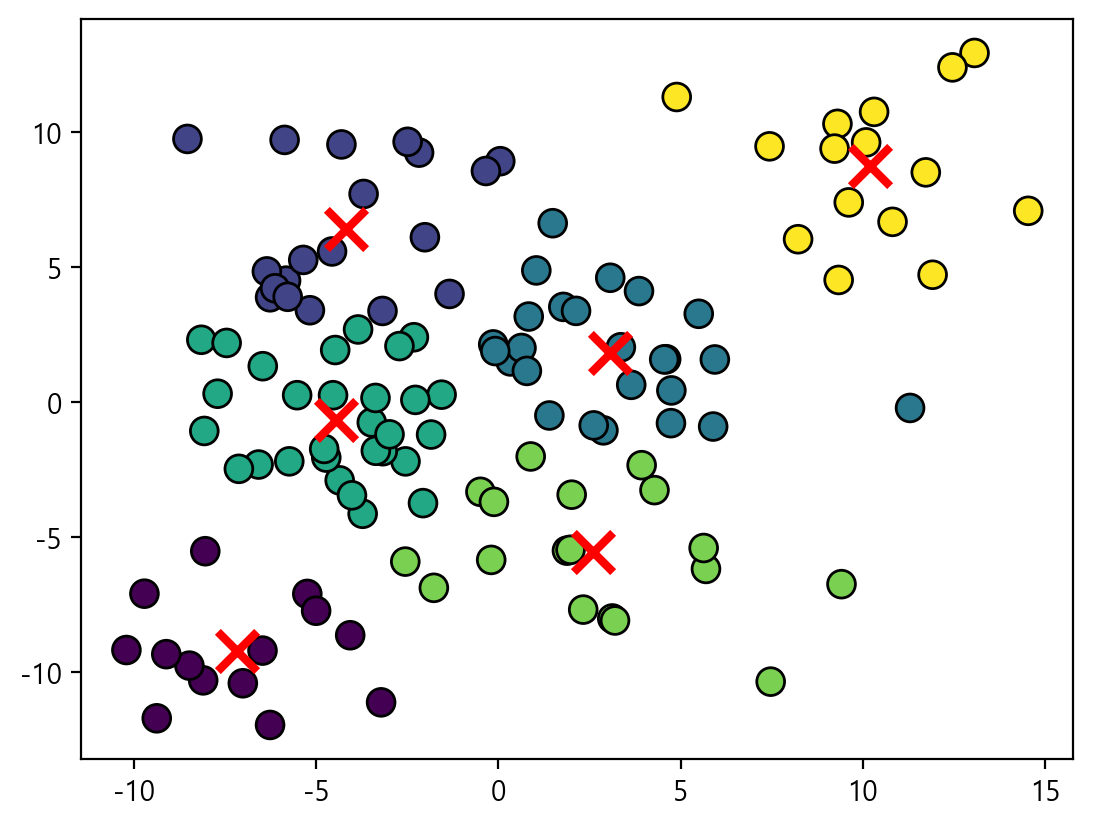

In [114]:
plt.scatter(x=data[:,0], y=data[:,1], c=pred, s=100, edgecolors='k')
plt.scatter(x=c[:,0], y=c[:,1], c='r', marker='x', s=200, lw=3)
plt.show()

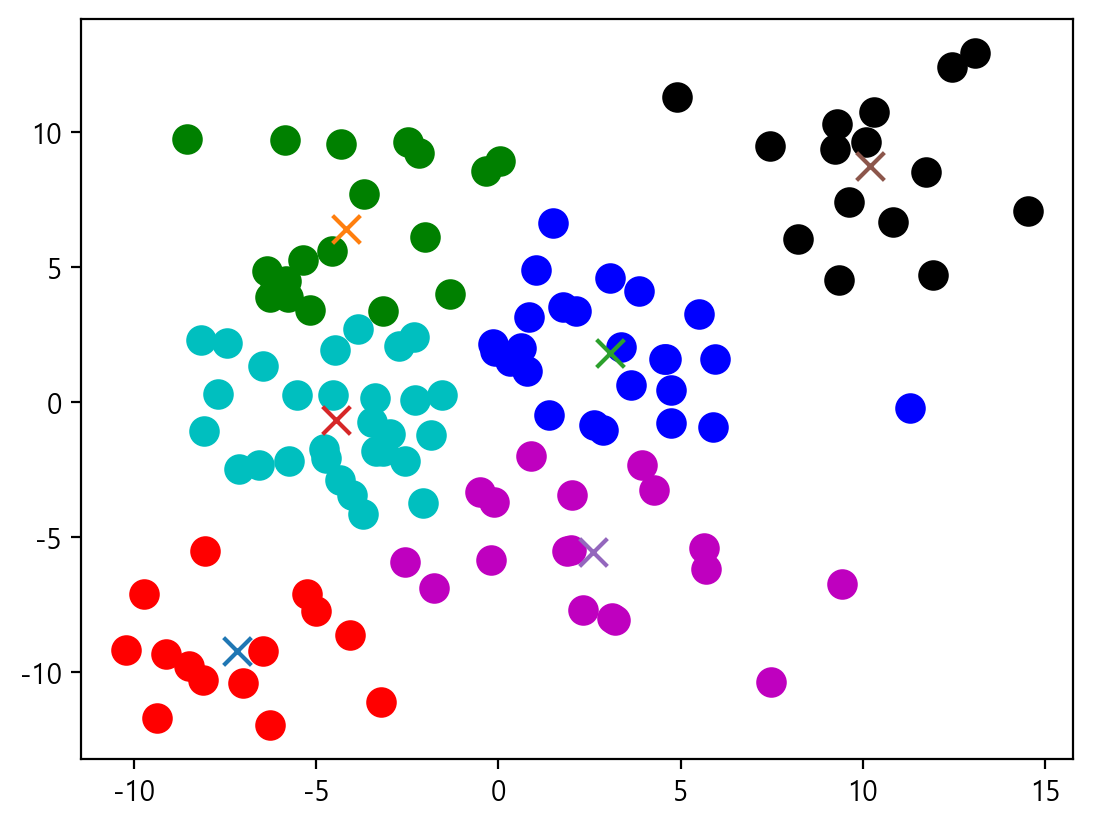

In [122]:
colors = ['r','g','b','c','m','k'] # 012345
for i in range(len(c)):
    plt.scatter(x=data[pred==i,0], y=data[pred==i,1], c=colors[i], s=100)
    plt.scatter(x=c[i,0], y=c[i,1], marker='x', s=100)

# 3절. Hierachical 클러스터링(계층적 군집)

- 계층적분석(linkage) -> dendrogram -> fcluster를 이용해서 클러스터를 생성(군집화)
    - 군끼리 묶으면서 최종적으로 하나의 군집이 될 때까지 묶는 클러스터링
    - 군집의 수를 미리 정해주지 않음
    - 군집간의 거리 기반으로 클러스터링

In [128]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.sample()

,sepal_length,sepal_width,petal_length,petal_width,species
86,6.7,3.1,4.7,1.5,versicolor


In [129]:
# 계층적 군집 적용을 위해 라벨 인코딩
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
iris.species = le.fit_transform(iris.species)

In [ ]:
from scipy.cluster.hierarchy import linkage
# method : 거리계산을 어떻게 할 지
# method="complete" : 두 클러스터에서 가장 먼 거리를 이용
# method="single" : 두 클러스터에서 가장 먼 거리를 이용
# method="average" : 두 클러스터내의 각 점에서 다른 클러스터의 모든 점의 평균거리 이용
cluster_model = linkage(iris, method='complete')


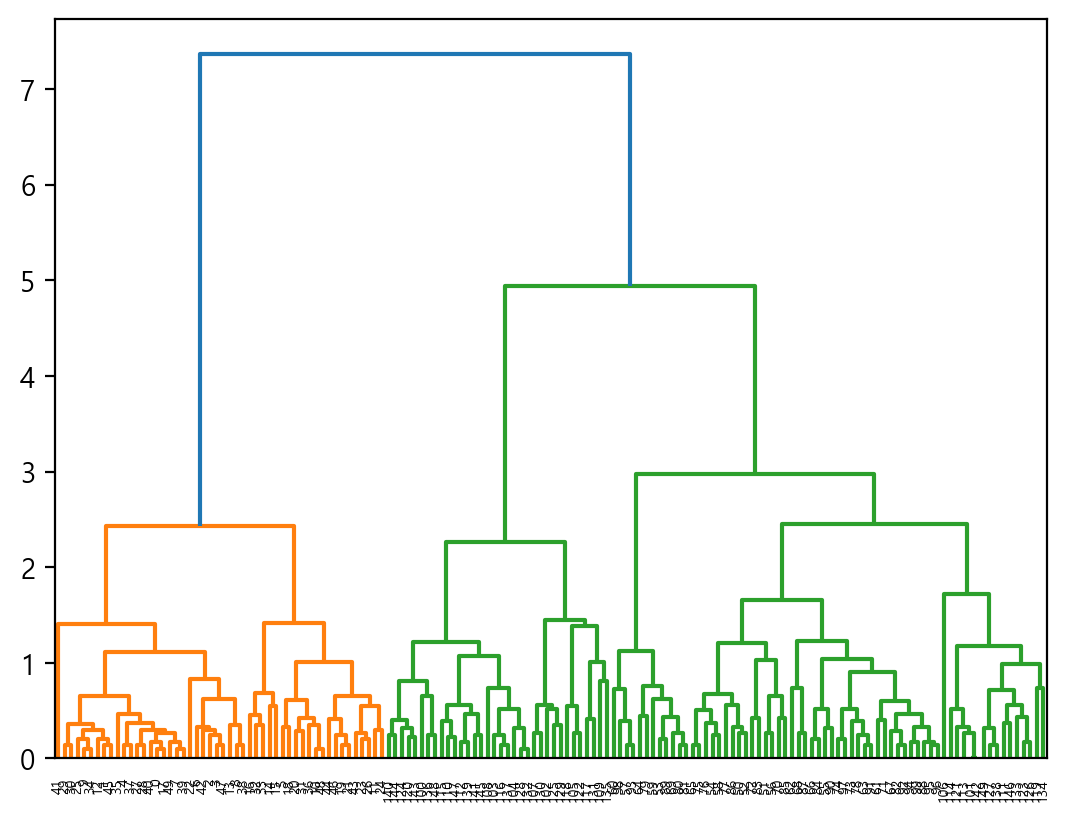

In [133]:
from scipy.cluster.hierarchy import dendrogram
dendrogram(cluster_model, labels=iris.index)
plt.savefig('data/ch02_iris.png', dpi=300, bbox_inches='tight')
plt.show()

In [134]:
from scipy.cluster.hierarchy import fcluster # 군집화
fcluster(cluster_model, 
         t=4, # dendrogram의 y축의 값
         criterion="distance") # 군집화 기준
# criterion="distance" 일 때, t값은 dendrogram의 y축 값

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2,
       2, 3, 2, 3, 3, 2, 2, 2, 2, 3, 2, 3, 2, 3, 2, 2, 3, 3, 2, 2, 2, 2,
       2, 3, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 3], dtype=int32)

In [135]:
fcluster(cluster_model,
        t=3,
        criterion="maxclust")
# criterion="maxclust" 일 때, t값은 클러스터의 갯수(군집화된 그룹 갯수)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2,
       2, 3, 2, 3, 3, 2, 2, 2, 2, 3, 2, 3, 2, 3, 2, 2, 3, 3, 2, 2, 2, 2,
       2, 3, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 3], dtype=int32)

In [136]:
fcluster(cluster_model, 5, criterion="distance")

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

# 4절. DBSCAN 클러스터링
- 연결 기반(밀도기반) 군집화 알고리즘(이상치를 자동 감지)
- 단점 : 클러스터의 밀도가 일정하지 않으면 성능이 낮아짐

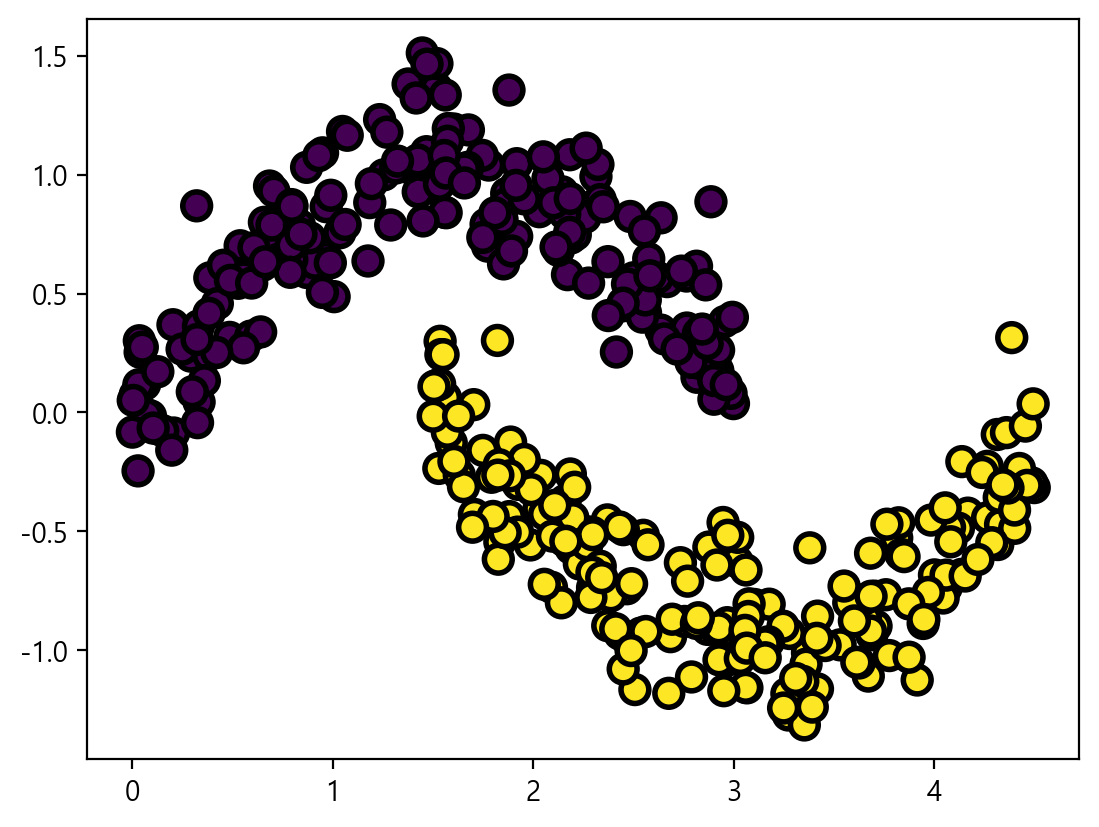

In [140]:
X1 = np.random.rand(200)*3 # 0<=X1<2의 실수 난수 200개
noise = np.random.normal(0, 0.2, 200)
Y1 = np.sin(X1) + noise
group1 = np.c_[X1, Y1, np.full(200, 0)]

X2 = X1 + 1.5
Y2 = np.cos(X2) + noise
group2 = np.c_[X2, Y2, np.full(200, 1)]
data = np.r_[group1, group2]

plt.scatter(data[:,0], data[:,1], c=data[:,2], s=100, edgecolors='k', lw=2)

In [142]:
db

DBSCAN(eps=0.3, min_samples=10)

In [141]:
from sklearn.cluster import DBSCAN
# 반경 0.3이내에 최소 10개는 있어야 군집 시작
db = DBSCAN(eps=0.3, min_samples=10)
db.fit(data)

DBSCAN(eps=0.3, min_samples=10)

In [147]:
labels = db.labels_     # 모델이 군집화한 결과(-1은 이상치 인식)
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0) # 클러스터 수
n_noise_ = list(labels).count(-1)
print(f'이상치를 제외한 클러스터수 : {n_clusters_}, 이상치 갯수 : {n_noise_}개')

이상치를 제외한 클러스터수 : 2, 이상치 갯수 : 1개


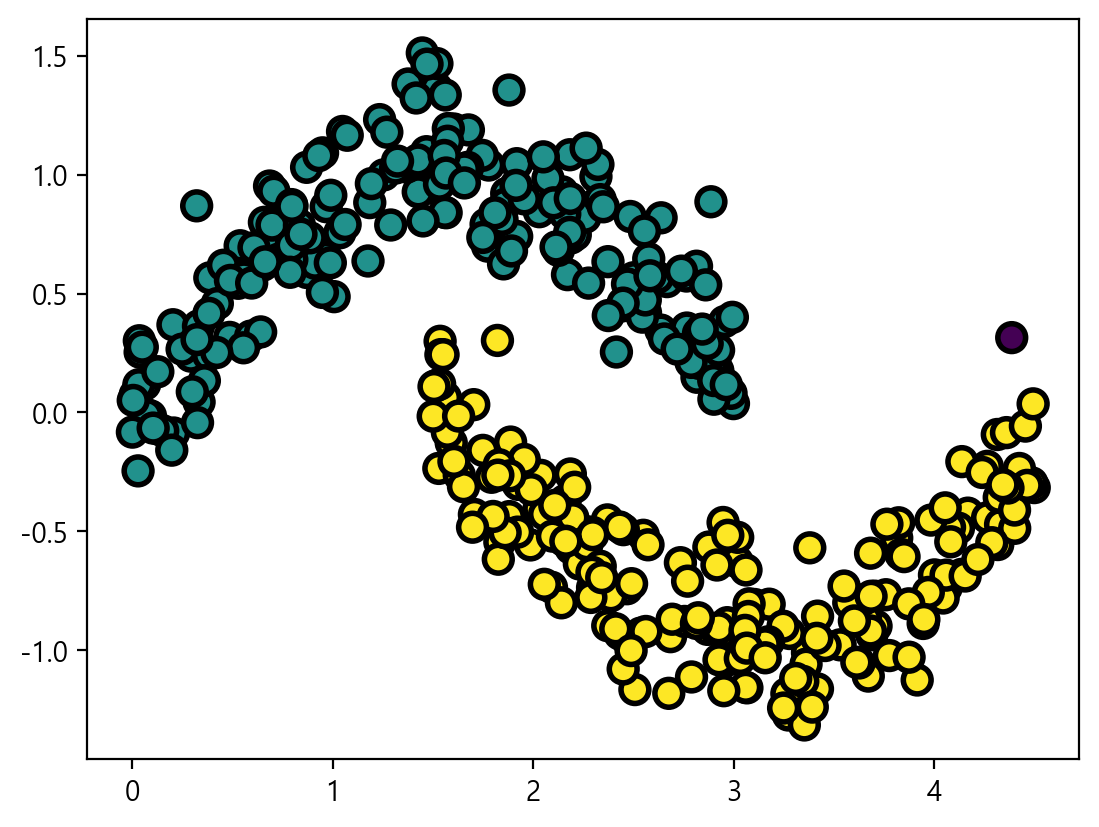

In [148]:
plt.scatter(data[:,0], data[:,1], c=labels, s=100, edgecolors='k', lw=2)

# 5절 모형 성능평가
- score메소드를 통해 예측 모형 평가(분류, 회귀. 군집에서는 안 씀)
- metrics 모듈의 메소드를 통해 군집 모형 평가
## 5.1 metrics 함수이용
    - 클러스터의 소속과 갯수를 모두 알고 있을 경우 평가

In [150]:
iris.sample()

,sepal_length,sepal_width,petal_length,petal_width,species
46,5.1,3.8,1.6,0.2,0


In [151]:
iris_X = iris.iloc[:,:-1]
iris_y = iris.iloc[:, -1]
iris_X.shape, iris_y.shape

((150, 4), (150,))

In [152]:
iris_model3 = KMeans(n_clusters=3, n_init=10, random_state=1)
iris_model3.fit(iris_X)


KMeans(n_clusters=3, n_init=10, random_state=1)

In [154]:
pred = iris_model3.labels_
pred = iris_model3.predict(iris_X)
pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0])

In [155]:
# pred 조정을 위해 : np.choose(배열시퀀스, 배열)
np.choose([3,2,2,3], [0,10,20,30])

array([30, 20, 20, 30])

In [156]:
np.choose([1,1,1,1,0,0,0,2,2,2], [1,0,2])

array([0, 0, 0, 0, 1, 1, 1, 2, 2, 2])

In [157]:
pred3 = np.choose(iris_model3.labels_, [1,0,2])
pred3 # 조정된 예측값

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 1, 1, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2,
       2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1])

In [158]:
# 3개 cluster로 군집화한 자료
print('실제값 :', iris_y[::50])
print('예측값 :', pred3[::50])


실제값 : 0      0
50     1
100    2
Name: species, dtype: int32
예측값 : [0 1 2]


In [160]:
iris_model2 = KMeans(n_clusters=2, n_init=10, random_state=1)
iris_model2.fit(iris_X)

KMeans(n_clusters=2, n_init=10, random_state=1)

In [161]:
pred2 = iris_model2.labels_

In [162]:
# 2개 cluster로 군집화한 자료
iris_y2 = np.array([0]*50 + [1]*100)
print('실제값 :', iris_y2)
print('예측값 :', pred2)

실제값 : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1]
예측값 : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1]
